# Fuzzy Fan Control

In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

In [6]:
# Temperature and Speed Ranges
temperature = np.arange(0, 41)
fan_speed = np.arange(0, 101)

In [36]:
temp_cold = fuzz.trimf(temperature, [0, 0, 20])
temp_warm = fuzz.trimf(temperature, [15, 20, 30])
temp_hot = fuzz.trimf(temperature, [25, 40, 40])

fan_slow = fuzz.trimf(fan_speed, [0, 0, 50])
fan_medium = fuzz.trimf(fan_speed, [25, 50, 75])
fan_fast = fuzz.trimf(fan_speed, [50, 100, 100])

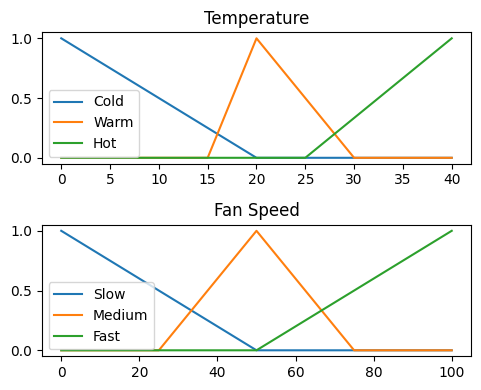

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(5, 4))

axes[0].plot(temperature, temp_cold, label='Cold')
axes[0].plot(temperature, temp_warm, label='Warm')
axes[0].plot(temperature, temp_hot, label='Hot')
axes[0].set_title('Temperature')
axes[0].legend()

axes[1].plot(fan_speed, fan_slow, label='Slow')
axes[1].plot(fan_speed, fan_medium, label='Medium')
axes[1].plot(fan_speed, fasn_fast, label='Fast')
axes[1].set_title('Fan Speed')
axes[1].legend()

plt.tight_layout()
plt.show()

In [70]:
temp_value = 18

In [71]:
cold_activation = fuzz.interp_membership(temperature, temp_cold, temp_value)
warm_activation = fuzz.interp_membership(temperature, temp_warm, temp_value)
hot_activation = fuzz.interp_membership(temperature, temp_hot, temp_value)

print('Temperature:', temp_value)
print('-'*30)
print('Cold activation:', cold_activation)
print('Warm activation:', warm_activation)
print('Hot activation:', hot_activation)
print('-'*30)
print('rule1 (cold -> slow):', cold_activation)
print('rule2 (warm -> medium):', warm_activation)
print('rule3 (hot -> fast):', hot_activation)

Temperature: 18
------------------------------
Cold activation: 0.1
Warm activation: 0.6
Hot activation: 0.0
------------------------------
rule1 (cold -> slow): 0.1
rule2 (warm -> medium): 0.6
rule3 (hot -> fast): 0.0


In [72]:
# Apply Rules
activated_slow = np.fmin(cold_activation, fan_slow)
activated_medium = np.fmin(warm_activation, fan_medium)
activated_fast= np.fmin(hot_activation, fan_fast)

In [73]:
# Aggregation
aggregated = np.fmax(activated_slow, np.fmax(activated_medium, activated_fast))

In [74]:
# Defuzzification
fan_output = fuzz.defuzz(fan_speed, aggregated, 'centroid')
print(f'Fan Speed Result: {fan_output:.2f} %')

Fan Speed Result: 45.90 %


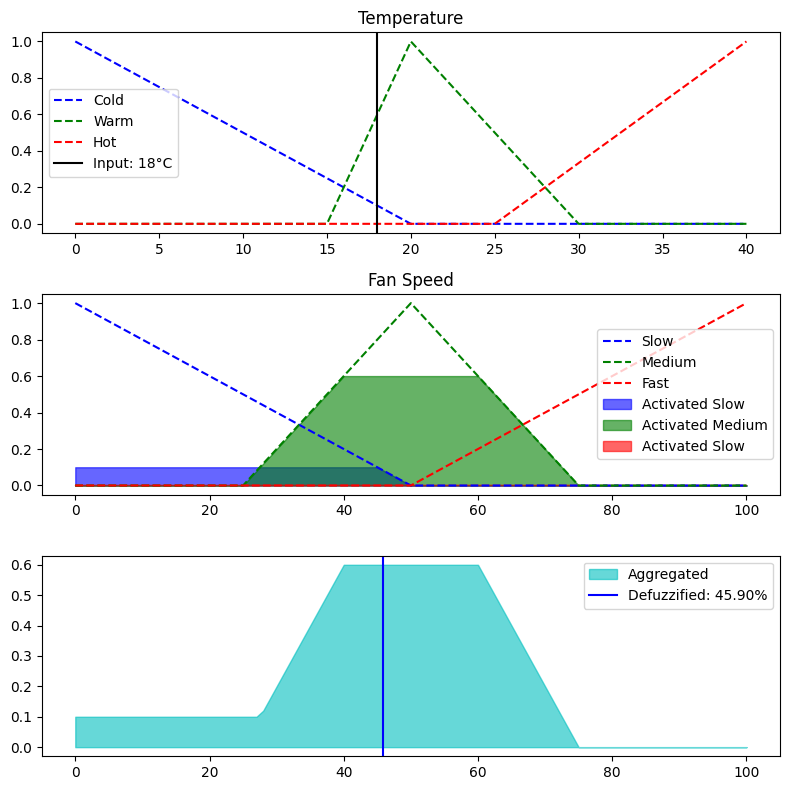

In [75]:
fig , axes = plt.subplots(3, 1, figsize=(8, 8))

axes[0].plot(temperature, temp_cold, 'b--', label='Cold')
axes[0].plot(temperature, temp_warm, 'g--', label='Warm')
axes[0].plot(temperature, temp_hot, 'r--', label='Hot')
axes[0].axvline(x=temp_value, color='k', linestyle='-', label=f'Input: {temp_value}°C')
axes[0].set_title('Temperature')
axes[0].legend()

axes[1].plot(fan_speed, fan_slow, 'b--', label='Slow')
axes[1].plot(fan_speed, fan_medium, 'g--', label='Medium')
axes[1].plot(fan_speed, fasn_fast, 'r--', label='Fast')
axes[1].fill_between(fan_speed, 0, activated_slow, alpha=0.6, color='b', label='Activated Slow')
axes[1].fill_between(fan_speed, 0, activated_medium, alpha=0.6, color='g', label='Activated Medium')
axes[1].fill_between(fan_speed, 0, activated_fast, alpha=0.6, color='r', label='Activated Slow')
axes[1].set_title('Fan Speed')
axes[1].legend()

axes[2].fill_between(fan_speed, 0, aggregated, alpha=0.6, color='c', label='Aggregated')
axes[2].axvline(x=fan_output, color='b', linestyle='-', label=f'Defuzzified: {fan_output:.2f}%')
axes[2].legend()

plt.tight_layout()
plt.show()

In [76]:
# Other defuzification methods
centroid = fuzz.defuzz(fan_speed, aggregated, 'centroid')
bisector = fuzz.defuzz(fan_speed, aggregated, 'bisector')
mom = fuzz.defuzz(fan_speed, aggregated, 'mom')
som = fuzz.defuzz(fan_speed, aggregated, 'som')
lom = fuzz.defuzz(fan_speed, aggregated, 'lom')

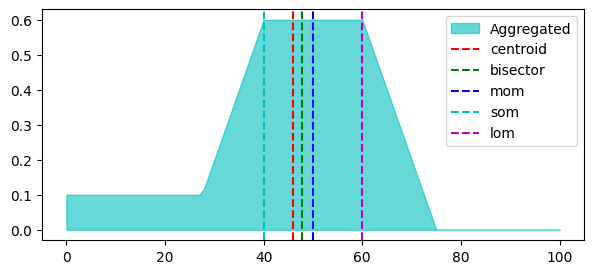

Temperature: 18
Centroid: 45.90 %
Bisector: 47.81 %
mom: 50.00 %
som: 40.00 %
lom: 60.00 %


In [77]:
plt.figure(figsize=(7, 3))

plt.fill_between(fan_speed, 0, aggregated, alpha=0.6, color='c', label='Aggregated')
plt.axvline(x=centroid, color='r', linestyle='--', label='centroid')
plt.axvline(x=bisector, color='g', linestyle='--', label='bisector')
plt.axvline(x=mom, color='b', linestyle='--', label='mom')
plt.axvline(x=som, color='c', linestyle='--', label='som')
plt.axvline(x=lom, color='m', linestyle='--', label='lom')
plt.legend()

plt.show()

print('Temperature:', temp_value)
print(f'Centroid: {centroid:.2f} %')
print(f'Bisector: {bisector:.2f} %')
print(f'mom: {mom:.2f} %')
print(f'som: {som:.2f} %')
print(f'lom: {lom:.2f} %')